In [ ]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :return: число -- значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактоного класса: Mean Squared Error лосс.

In [ ]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :return: число -- значения функции потерь
        """

        X_dot_w_y = X @ w - y
        loss = X_dot_w_y @ X_dot_w_y.T / y.shape[0]
        return loss

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """

        grad = 2 * X.T @ (X @ w - y) / y.shape[0]
        return grad

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [ ]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    # -- YOUR CODE HERE --
    w = w_init.copy()
    trace = np.zeros((n_iterations, X.shape[1]))
    trace[0, :] = w
    for i in range(1, n_iterations):
        trace[i, :] = trace[i - 1, :] -  lr * loss.calc_grad(X, y, trace[i - 1, :])
    return list(trace)

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории:

In [ ]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [ ]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450253
0.8670644395649652


In [ ]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # visualize the level set
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # visualize trajectory
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

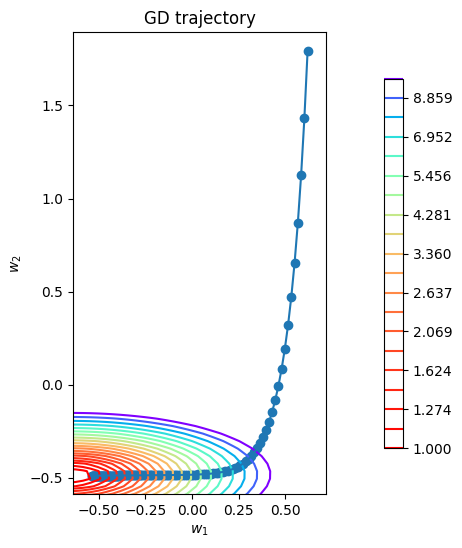

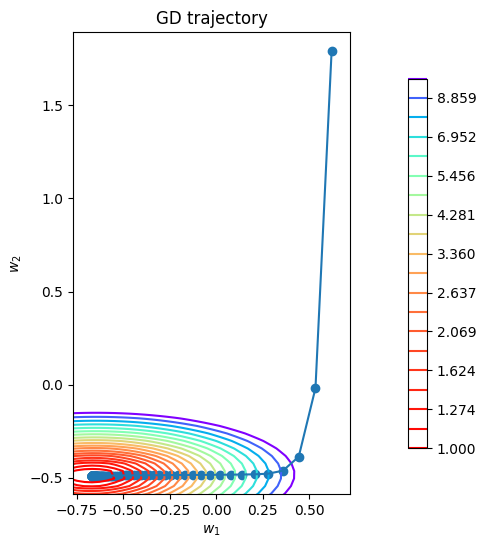

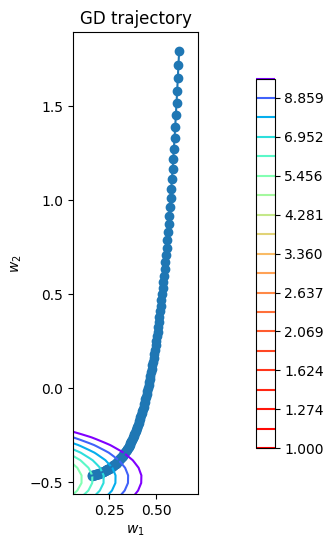

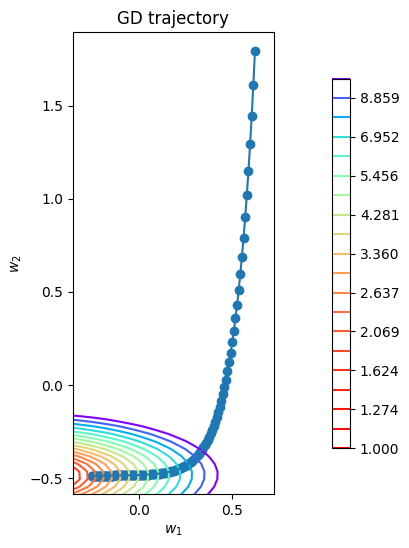

In [ ]:
lr_list = [0.001, 0.005, 0.0002, 0.0005]
loss = MSELoss()
for lr in lr_list:
    plot_gd(gradient_descent(w_init, X, y, loss, lr, 150), X, y, loss)

Теперь реализуем стохастический градиентный спуск

In [ ]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    X_batch_id = np.random.choice(X.shape[0], size=batch_size)
    X_batch = X[X_batch_id, :]
    y_batch = y[X_batch_id]
    w = w_init.copy()
    trace = np.zeros((n_iterations, X.shape[1]))
    trace[0, :] = w
    for i in range(1, n_iterations):
        trace[i, :] = trace[i - 1, :] -  lr * loss.calc_grad(X_batch, y_batch, trace[i - 1, :])
    return list(trace)

    

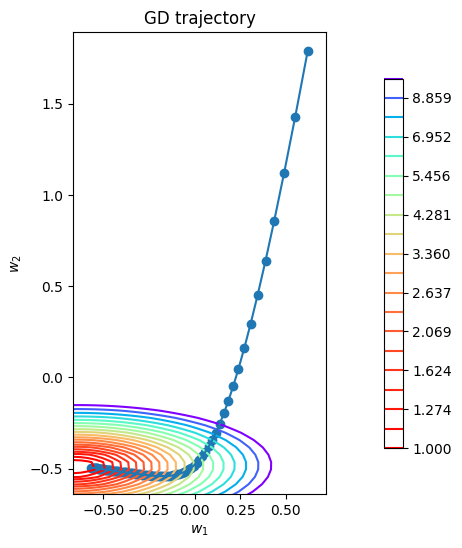

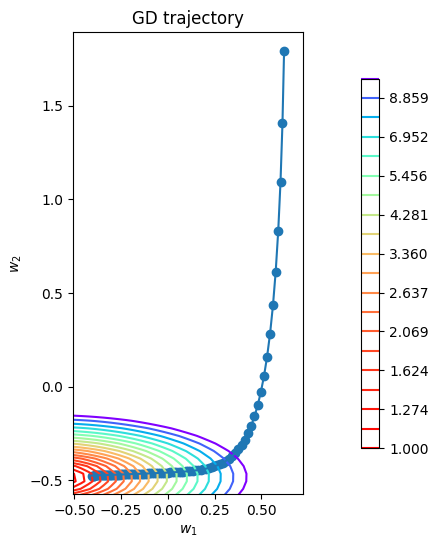

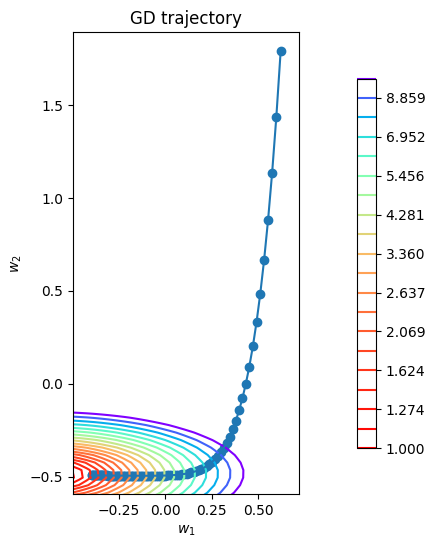

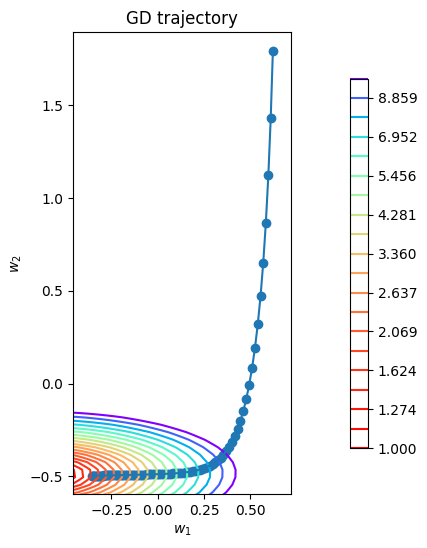

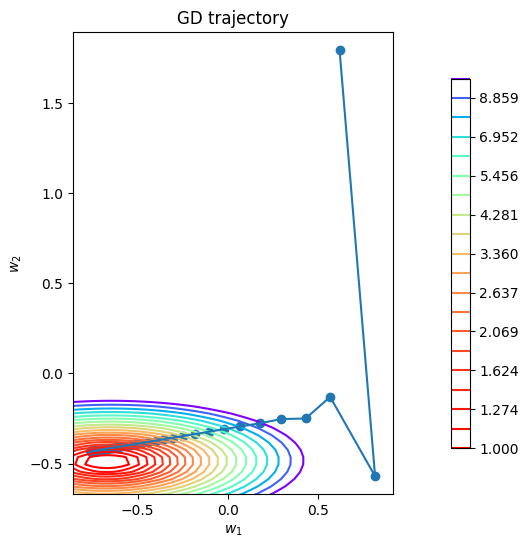

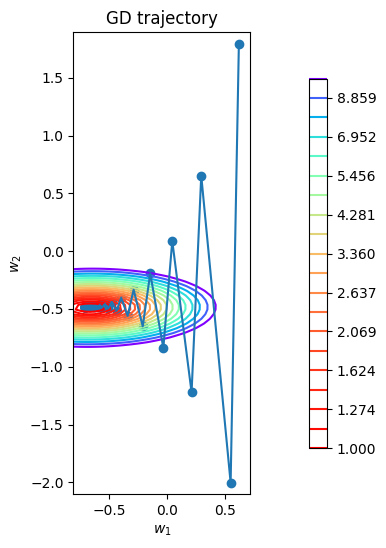

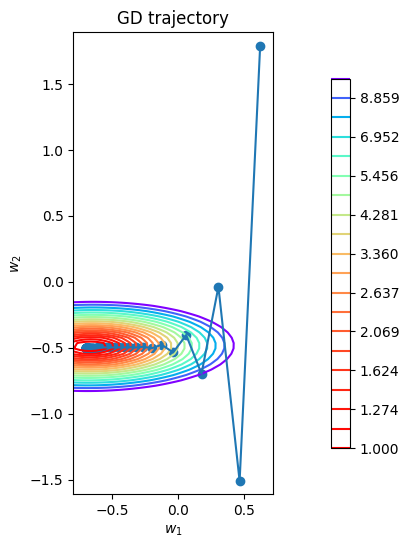

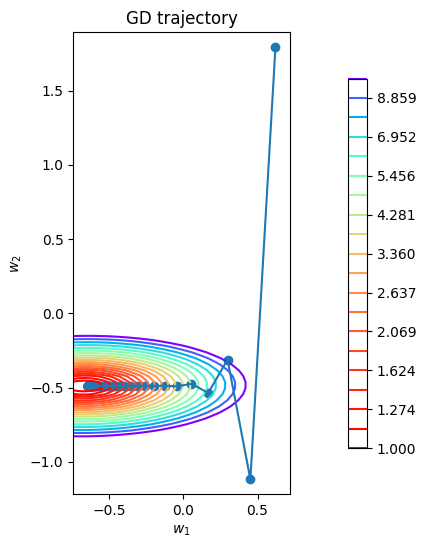

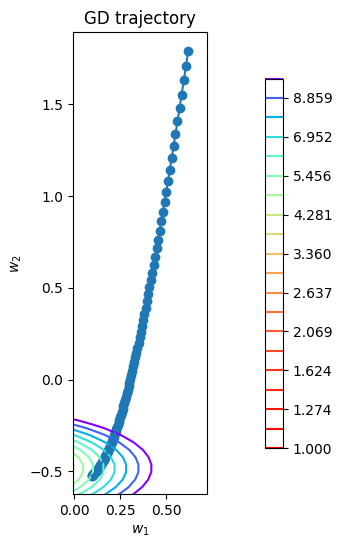

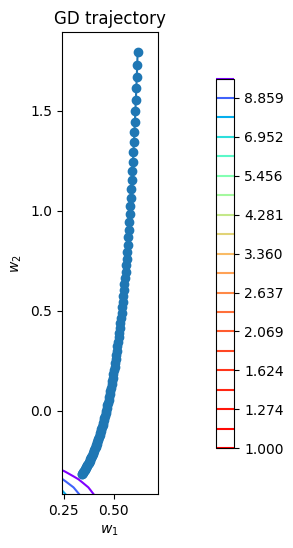

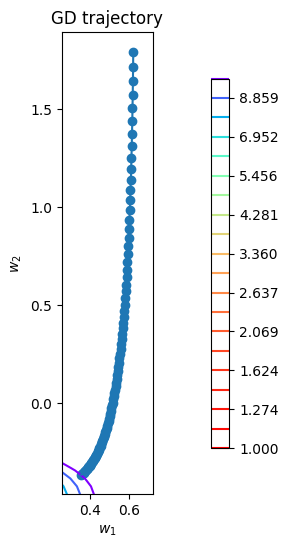

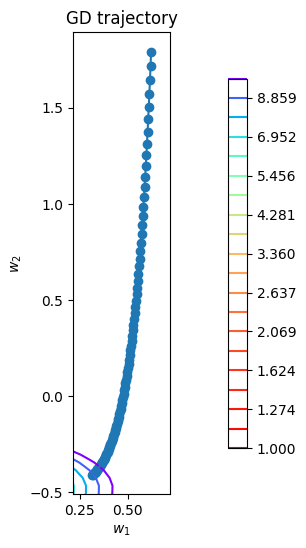

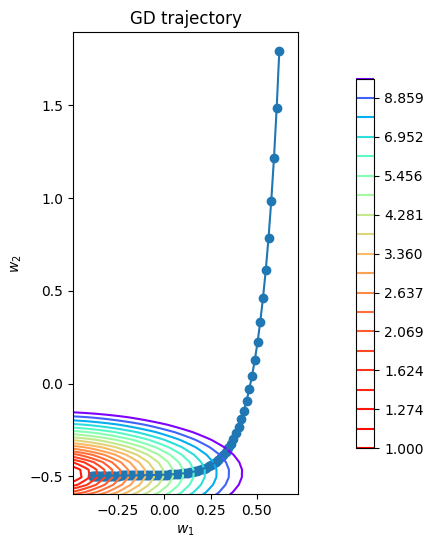

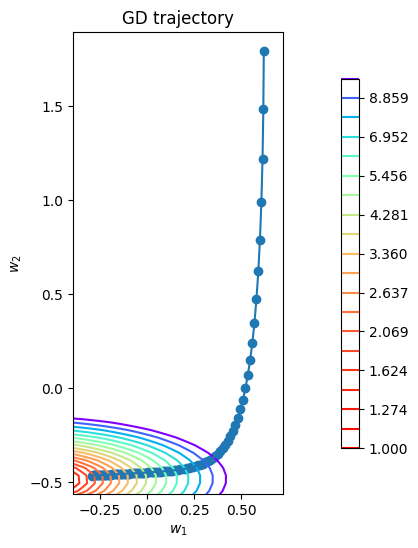

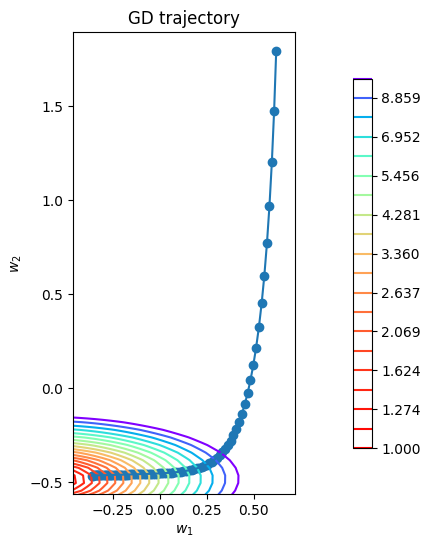

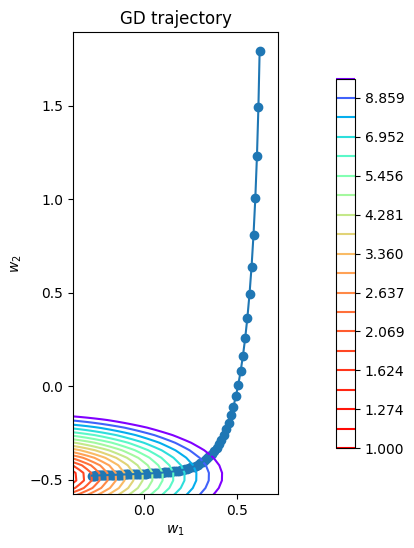

In [ ]:
lr_list = [0.001, 0.009, 0.0002, 0.0009]
batch_list = [10, 50, 150, 300]
loss = MSELoss()
for lr in lr_list:
    for batch_size in batch_list:
        plot_gd(stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, 100), X, y, loss)

Реализуем функцию `stochastic_gradient_descent` на этот раз с затухающим шагом. С параметром s = 1

In [ ]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    X_batch_id = np.random.choice(X.shape[0], size=batch_size)
    X_batch = X[X_batch_id, :]
    y_batch = y[X_batch_id]
    w = w_init.copy()
    trace = np.zeros((n_iterations, X.shape[1]))
    trace[0, :] = w
    for i in range(1, n_iterations):
        lr_i = lr * (1 / (1 + i))**p
        trace[i, :] = trace[i - 1, :] -  lr_i * loss.calc_grad(X_batch, y_batch, trace[i - 1, :])
    return list(trace)


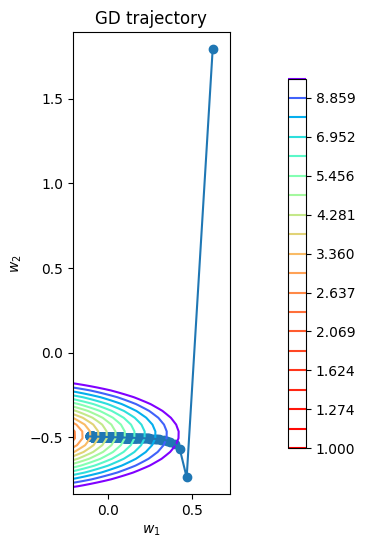

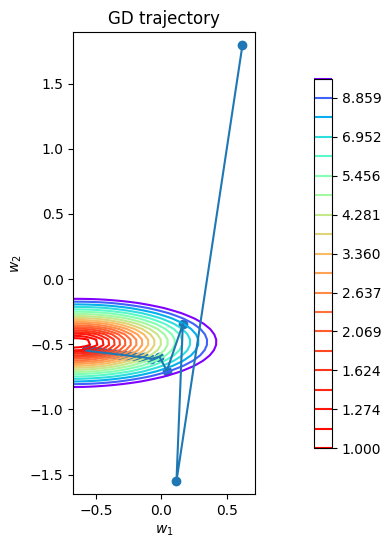

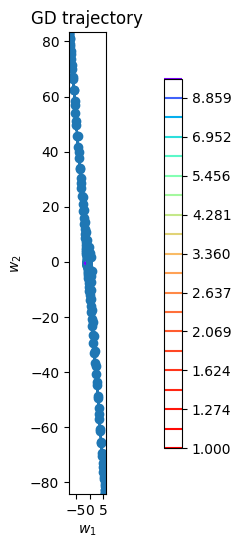

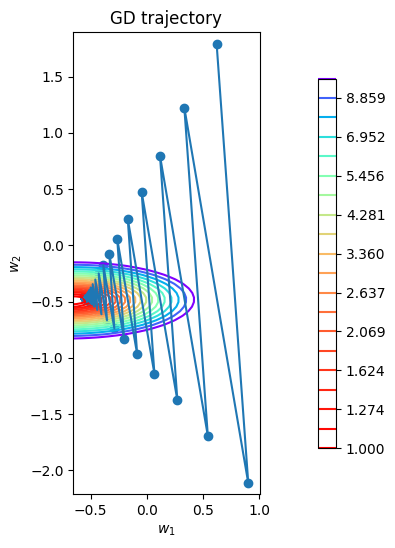

In [ ]:
ps = [1, 0.1, 0.05, 0.001]
for p in ps:
    plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, p), X, y, loss)

Сравним сходимость обычного градиентного спуска и стохастичекой версии

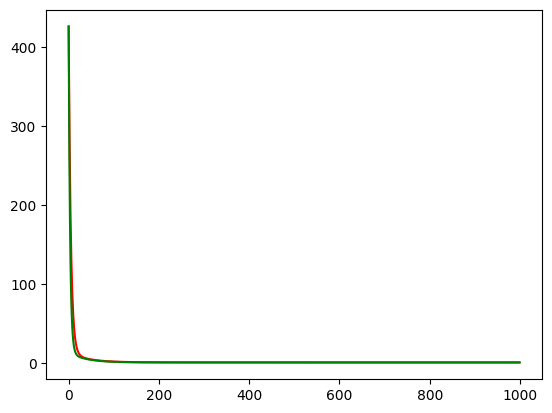

In [ ]:
# loss - i
rl = 0.009
batch_size = 10
loss = MSELoss()
SGD = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, p)
GD = gradient_descent(w_init, X, y, loss, lr)
SGD_Loss = [loss.calc_loss(X, y, SGD[i]) for i in range(1000)]
GD_Loss = [loss.calc_loss(X, y, GD[i]) for i in range(1000)]
plt.plot(range(1000), SGD_Loss, color='r')
plt.plot(range(1000), GD_Loss, color='g')



Линейная регрессия

In [ ]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака w0
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        w_start = np.random.uniform(-0.1, 0.1, X.shape[1])
        trace = gradient_descent(w_start, X, y, self.loss, self.lr, n_iterations=100000)
        self.w = trace[-1]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        #print(X.size, len(self.w))
        return X @ self.w

In [ ]:
linear_regression = LinearRegression(MSELoss())

In [ ]:
import pandas as pd

X_raw = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data",
    header=None,
    na_values=["?"],
)
X_raw.head()
X_raw = X_raw[~X_raw[25].isna()].reset_index()

In [ ]:
y = X_raw[25]
X_raw = X_raw.drop(25, axis=1)
X_raw = X_raw.drop("index", axis=1)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Приводим имена признаков к строковому типу для работы SimpleImputer
X_raw.columns = X_raw.columns.astype(str)

#Разделяем числовые и нечисловые признаки
cat_features_mask = (X_raw.dtypes == "object")
cat_features = X_raw.columns[cat_features_mask]
num_features = X_raw.columns[~cat_features_mask]
#Заменяем пропуски в числовых признаках на среднее
SI = SimpleImputer(strategy="mean")
X_raw[num_features] = SI.fit_transform(X_raw[num_features])
#Заменяем пропуски в числовых признаках на "None"
X_raw[cat_features].fillna("None")

#Нормализуем числовые признаки
norm = StandardScaler()
X_raw[num_features] = norm.fit_transform(X_raw[num_features])

#Закодируем категориальные переменные с помощью dummies (One-hot)
X_raw = pd.get_dummies(X_raw, drop_first=True, dtype=int)

#Разделим обработанный датасет на обучающую и тeстовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=0)

,2,3,4,5,6,7,8,14,15,17
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
196,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
197,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
198,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
199,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


Обучим написанную линейную регрессию на обучающей выборке

In [ ]:
linear_regression.fit(X_train, y_train)

Посчитаем ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_train = linear_regression.predict(X_train)
y_pred_test = linear_regression.predict(X_test)

train_error = mean_squared_error(y_train, y_pred_train)
test_error = mean_squared_error(y_test, y_pred_test)

rmse_train = np.sqrt(np.mean((y_pred_train - y_train)**2))
rmse_test = np.sqrt(np.mean((y_pred_test - y_test)**2))

print("mse train", train_error, "nmse train", rmse_train/np.mean(y_train))
print("mse test", test_error, "nmse test", rmse_test/np.mean(y_test))


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию.

In [ ]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :output: число -- значения функции потерь
        """
        X_dot_w_y = X @ w - y
        L2 = self.coef * w[:-1] @ w[:-1].T
        return (X_dot_w_y @ X_dot_w_y.T + L2) / y.shape[0]

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        w[-1] = 0
        grad = (2 * X.T @ (X @ w - y) + 2* self.coef * w) / y.shape[0]
        return grad

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [ ]:
linear_regression = LinearRegression(MSEL2Loss(1**(-2)))

Обучим регрессию с лоссом `MSEL2Loss` и добьемся улучшения результата на тестовой выборке.

In [ ]:
linear_regression.fit(X_train, y_train)

y_pred_train = linear_regression.predict(X_train)
y_pred_test = linear_regression.predict(X_test)

train_error = mean_squared_error(y_train, y_pred_train)
test_error = mean_squared_error(y_test, y_pred_test)

rmse_train = np.sqrt(np.mean((y_pred_train - y_train)**2))
rmse_test = np.sqrt(np.mean((y_pred_test - y_test)**2))

print("mse train", train_error, "nmse train", rmse_train/np.mean(y_train))
print("mse test", test_error, "nmse test", rmse_test/np.mean(y_test))

В нашем датасете могут быть выбросы. С выбросами хорошо помогает бороться Huber Loss. Давайте его реализуем и применим в нашей регрессии.

In [ ]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :output: число -- значения функции потерь
        """
        error = X.dot(w) - y
        mse = 0.5 * error ** 2
        mae = self.eps * (np.abs(error) - self.eps/2) 
        mask = np.abs(error) < self.eps 
        loss = np.where(mask, mse, mae)
        return loss.mean()
        
    

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        error = X.dot(w) - y
        grad1 = (error) 
        grad2 = ( np.sign(error) * self.eps) 
        grad = np.where(np.abs(error) < self.eps, grad1, grad2 )
        grad = X.T @ grad / y.shape[0]
        return grad

Обучим регрессию с лоссом `HuberLoss`. 

In [ ]:
linear_regression = LinearRegression(HuberLoss(500))

In [ ]:
linear_regression.fit(X_train, y_train)

y_pred_train = linear_regression.predict(X_train)
rmse_train = np.sqrt(np.mean((y_pred_train - y_train)**2))

y_pred_test = linear_regression.predict(X_test)
rmse_test = np.sqrt(np.mean((y_pred_test - y_test)**2))

print("mse train", train_error, "nmse train", rmse_train/np.mean(y_train))
print("mse test", test_error, "nmse test", rmse_test/np.mean(y_test))